# Notebook 15 – Model Optimization Pipeline

**Dataset:** Online Retail transactions (`data.csv`)

**Problem:** Flag **international orders** (non-UK, ~11% of data) — an imbalanced classification problem.

**Workflow (15 steps):** Load → Preprocess → Engineer features → Split → Baseline → Multiple models → Evaluate → Cross-validate → Identify overfitting → Tune → Optimize threshold → Compare → Error analysis → Explain → Select final model.

Preprocessing is built into a scikit-learn **Pipeline**, so the same steps are applied identically in training, cross validation and prediction (no data leakage).

## 1. Load Dataset

In [20]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
                             f1_score, confusion_matrix, precision_recall_curve)
raw = pd.read_csv('data.csv', encoding='latin1')
print("Raw shape:", raw.shape)
raw.head(3)

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


## 2. Preprocess Data
- Drop rows with no `CustomerID`.
- Remove returns/errors (non-positive quantity or price).
- Parse dates and take an 8,000-row sample for speed.

Scaling and encoding are added later inside the Pipeline.

In [21]:
df = raw.dropna(subset=['CustomerID'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df.sample(8000, random_state=42).copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Clean shape:", df.shape)
print("Missing values:", int(df[['Quantity', 'UnitPrice', 'InvoiceDate', 'Country']].isnull().sum().sum()))

Clean shape: (8000, 8)
Missing values: 0


## 3. Engineer Features
Create total price, time features, a time-of-day **category**, and a large-order flag. The target is `1` = international.

In [22]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Month'] = df['InvoiceDate'].dt.month
df['TimeOfDay'] = pd.cut(df['Hour'], [0, 9, 12, 15, 24], labels=['Early', 'LateMorning', 'Afternoon', 'Evening']).astype(str)
df['IsLargeOrder'] = (df['Quantity'] >= 12).astype(int)
numeric_features = ['Quantity', 'UnitPrice', 'TotalPrice', 'Hour', 'DayOfWeek', 'Month', 'IsLargeOrder']
categorical_features = ['TimeOfDay']
X = df[numeric_features + categorical_features]
y = (df['Country'] != 'United Kingdom').astype(int)
preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

## 4. Split Data
Stratified split keeps the same international share in train and test.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("International share (train / test):", round(y_train.mean(), 3), "/", round(y_test.mean(), 3))

Train: (6400, 8) | Test: (1600, 8)
International share (train / test): 0.111 / 0.111


## 5. Establish Baseline
Always predicting the majority class. Real models must beat this on ROC-AUC and F1 — accuracy is misleading here.

In [24]:
baseline = Pipeline([('prep', preprocess), ('model', DummyClassifier(strategy='most_frequent'))]).fit(X_train, y_train)
b_pred = baseline.predict(X_test)
print("Baseline accuracy:", round((b_pred == y_test).mean(), 3))
print("Baseline F1:      ", round(f1_score(y_test, b_pred, zero_division=0), 3))
print("Baseline ROC-AUC: ", round(roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1]), 3))

Baseline accuracy: 0.889
Baseline F1:       0.0
Baseline ROC-AUC:  0.5


## 6. Train Multiple Models
Each model is wrapped in a Pipeline with the same preprocessing. The unlimited Decision Tree is included to show overfitting.

In [25]:
def make(model):
    return Pipeline([('prep', preprocess), ('model', model)])

models = {
    'Logistic Regression': make(LogisticRegression(max_iter=1000)),
    'Decision Tree (no limit)': make(DecisionTreeClassifier(random_state=42)),
    'Decision Tree (depth 5)': make(DecisionTreeClassifier(max_depth=5, random_state=42)),
    'Random Forest': make(RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)),
    'Gradient Boosting': make(GradientBoostingClassifier(random_state=42)),
}
for m in models.values():
    m.fit(X_train, y_train)
print("Trained:", list(models))

Trained: ['Logistic Regression', 'Decision Tree (no limit)', 'Decision Tree (depth 5)', 'Random Forest', 'Gradient Boosting']


## 7. Evaluate Models
Test-set metrics at the **default threshold (0.5)**. Notice recall is very low — we fix this in step 11.

In [26]:
def evaluate(model, threshold=0.5):
    p = model.predict_proba(X_test)[:, 1]
    pred = (p >= threshold).astype(int)
    return {
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, p),
        'PR-AUC': average_precision_score(y_test, p),
    }
eval_table = pd.DataFrame({name: evaluate(m) for name, m in models.items()}).T.round(3)
eval_table

,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.500,0.011,0.022,0.681,0.196
Decision Tree (no limit),0.182,0.225,0.201,0.549,0.128
Decision Tree (depth 5),0.500,0.051,0.092,0.688,0.201
Random Forest,0.667,0.034,0.064,0.753,0.281
Gradient Boosting,0.692,0.051,0.094,0.748,0.305


## 8. Perform Cross Validation
5-fold stratified CV on the **training data only**. The mean shows expected performance; the std shows stability.

In [27]:
cv_results = {name: cross_validate(m, X_train, y_train, cv=skf, scoring='roc_auc', return_train_score=True)
              for name, m in models.items()}
cv_table = pd.DataFrame({
    'CV ROC-AUC (mean)': {n: r['test_score'].mean() for n, r in cv_results.items()},
    'CV ROC-AUC (std)': {n: r['test_score'].std() for n, r in cv_results.items()},
}).round(3)
cv_table.sort_values('CV ROC-AUC (mean)', ascending=False)

,CV ROC-AUC (mean),CV ROC-AUC (std)
Gradient Boosting,0.753,0.012
Random Forest,0.746,0.010
Decision Tree (depth 5),0.717,0.018
Logistic Regression,0.687,0.024
Decision Tree (no limit),0.571,0.012


## 9. Identify Overfitting
Compare **train AUC** with **CV AUC**. A large gap means the model memorizes the training data.

In [28]:
gap_table = pd.DataFrame({
    'Train AUC': {n: r['train_score'].mean() for n, r in cv_results.items()},
    'CV AUC': {n: r['test_score'].mean() for n, r in cv_results.items()},
})
gap_table['Gap'] = gap_table['Train AUC'] - gap_table['CV AUC']
gap_table['Verdict'] = np.where(gap_table['Gap'] > 0.10, 'Overfitting',
                         np.where(gap_table['CV AUC'] < 0.66, 'Underfitting (weak)', 'OK'))
gap_table.round(3).sort_values('Gap', ascending=False)

,Train AUC,CV AUC,Gap,Verdict
Decision Tree (no limit),1.000,0.571,0.429,Overfitting
Random Forest,0.906,0.746,0.160,Overfitting
Gradient Boosting,0.830,0.753,0.078,OK
Decision Tree (depth 5),0.755,0.717,0.038,OK
Logistic Regression,0.693,0.687,0.006,OK


## 10. Tune Hyperparameters
Gradient Boosting has the strongest CV AUC, so we tune it with `RandomizedSearchCV`. In a Pipeline, parameters are prefixed with the step name (`model__`).

In [29]:
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__min_samples_leaf': [5, 20, 50],
}
search = RandomizedSearchCV(make(GradientBoostingClassifier(random_state=42)), param_dist,
                            n_iter=8, cv=3, scoring='roc_auc', random_state=42)
search.fit(X_train, y_train)
tuned = search.best_estimator_
models['Gradient Boosting (tuned)'] = tuned
print("Best params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 3))

Best params: {'model__subsample': 0.85, 'model__n_estimators': 200, 'model__min_samples_leaf': 20, 'model__max_depth': 2, 'model__learning_rate': 0.1}
Best CV AUC: 0.751


## 11. Optimize Classification Threshold
With rare positives, the default 0.5 threshold misses most of them. For **every** model we pick the threshold that maximizes F1 using **cross-validated predictions on the training data** (never the test set).

In [30]:
def best_threshold(model):
    oof = cross_val_predict(model, X_train, y_train, cv=skf, method='predict_proba')[:, 1]
    prec, rec, thr = precision_recall_curve(y_train, oof)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    return thr[f1[:-1].argmax()]
thresholds = {name: best_threshold(m) for name, m in models.items()}
pd.Series(thresholds).round(3).rename('Best threshold')

Logistic Regression          0.101
Decision Tree (no limit)     0.500
Decision Tree (depth 5)      0.099
Random Forest                0.145
Gradient Boosting            0.164
Gradient Boosting (tuned)    0.158
Name: Best threshold, dtype: float64

## 12. Compare Models
Final comparison: CV score for stability, plus test metrics at each model's **own optimized threshold**.

In [31]:
rows = []
for name, m in models.items():
    r = evaluate(m, thresholds[name])
    cv = cross_validate(m, X_train, y_train, cv=skf, scoring='roc_auc', return_train_score=True)
    rows.append({
        'Model': name,
        'CV ROC-AUC': cv['test_score'].mean(),
        'Test ROC-AUC': r['ROC-AUC'],
        'Precision': r['Precision'],
        'Recall': r['Recall'],
        'F1': r['F1'],
        'Train-CV Gap': cv['train_score'].mean() - cv['test_score'].mean(),
    })
comparison = pd.DataFrame(rows).set_index('Model').round(3).sort_values('CV ROC-AUC', ascending=False)
comparison

,CV ROC-AUC,Test ROC-AUC,Precision,Recall,F1,Train-CV Gap
Model,,,,,,
Gradient Boosting (tuned),0.755,0.750,0.206,0.551,0.300,0.057
Gradient Boosting,0.753,0.748,0.209,0.545,0.302,0.078
Random Forest,0.746,0.753,0.198,0.685,0.307,0.160
Decision Tree (depth 5),0.717,0.688,0.165,0.888,0.278,0.038
Logistic Regression,0.687,0.681,0.182,0.685,0.288,0.006
Decision Tree (no limit),0.571,0.549,0.182,0.225,0.201,0.429


## 13. Perform Error Analysis
We analyze the tuned Gradient Boosting model at its optimized threshold.

In [32]:
final_model = models['Gradient Boosting (tuned)']
final_thr = thresholds['Gradient Boosting (tuned)']
probs = final_model.predict_proba(X_test)[:, 1]
err = X_test.copy()
err['y_true'] = y_test.values
err['y_pred'] = (probs >= final_thr).astype(int)
err['Country'] = df.loc[X_test.index, 'Country']
err['ErrorType'] = np.where((err.y_true == 1) & (err.y_pred == 0), 'FN',
                     np.where((err.y_true == 0) & (err.y_pred == 1), 'FP', 'OK'))
print(err['ErrorType'].value_counts().to_dict())
print("\nError rate by time of day:")
print((err.ErrorType != 'OK').groupby(err['TimeOfDay']).mean().round(3))

{'OK': 1143, 'FP': 377, 'FN': 80}

Error rate by time of day:
TimeOfDay
Afternoon      0.239
Early          0.711
Evening        0.162
LateMorning    0.290
Name: ErrorType, dtype: float64


In [33]:
print("Error rate by order size:")
print((err.ErrorType != 'OK').groupby(err['IsLargeOrder']).mean().round(3).rename({0: 'Small (<12)', 1: 'Large (12+)'}))
print("\nMissed international orders by country (top 5):")
print(err[err.ErrorType == 'FN']['Country'].value_counts().head(5))

Error rate by order size:
IsLargeOrder
Small (<12)    0.206
Large (12+)    0.458
Name: ErrorType, dtype: float64

Missed international orders by country (top 5):
Country
Germany     18
France      13
EIRE        13
Spain        8
Portugal     5
Name: count, dtype: int64


## 14. Explain Model
**Permutation importance** on the test set (works directly on the Pipeline): how much does ROC-AUC drop when each feature is shuffled?

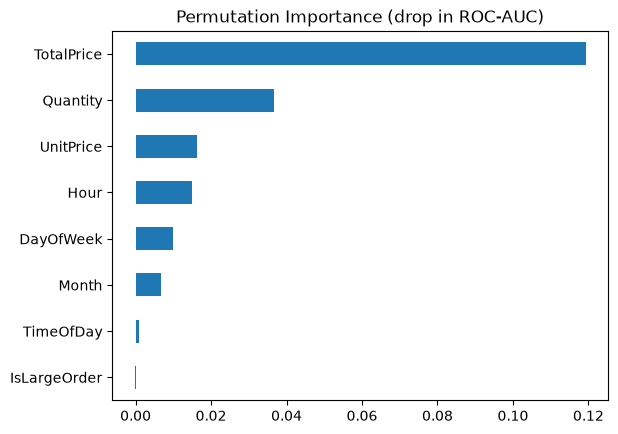

In [34]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(final_model, X_test, y_test, scoring='roc_auc', n_repeats=5, random_state=42)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
importance.plot(kind='barh', title='Permutation Importance (drop in ROC-AUC)')
plt.show()

## 15. Select Final Model
Summary of the candidates on the test set, using the metrics that matter for this problem.

In [35]:
final_table = pd.DataFrame({
    'Baseline (always UK)': {'Accuracy': (b_pred == y_test).mean(), 'Precision': 0, 'Recall': 0, 'F1': 0, 'ROC-AUC': 0.5},
    'Final model (tuned GB + threshold)': {
        'Accuracy': ((probs >= final_thr).astype(int) == y_test).mean(),
        **{k: v for k, v in evaluate(final_model, final_thr).items() if k != 'PR-AUC'},
    },
}).T.round(3)
final_table

,Accuracy,Precision,Recall,F1,ROC-AUC
Baseline (always UK),0.889,0.000,0.000,0.0,0.50
Final model (tuned GB + threshold),0.714,0.206,0.551,0.3,0.75
